# Credit Card Churn Analysis

## Notebook 1: Data Audit + Exploratory Data Analysis

**Objective:** Understand the dataset structure, identify data quality issues, and explore patterns that drive customer churn.

**Business Context:** Customer acquisition costs in retail banking are estimated at 5x to 25x the cost of retention.A churn model that flags at-risk customers enables targeted retention offers (fee waivers, credit limit increases, personalised outreach), turning a passive metric into an actionable lever.

**Dataset:** BankChurners: 10,127 customers, 23 features  

**Target Variable:** `Attrition_Flag` → encoded as binary, `Churn` (1 = churned, 0 = active)  

**Churn Rate:** 16.1% (class imbalance present, accuracy is not the evaluation metric)

**Notebook Structure:** 
1. Data Audit : quality checks, leakage removal, target encoding
2. Univariate EDA : distributions and outliers per feature
3. Bivariate EDA : feature behaviour stratified by churn
4. Key Findings : handoff to Notebook 02 (Feature Engineering)
5. Business Questions(5) : quantified answers for stakeholder discussion

## Import Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

---
## Section 1: Data Audit

### 1.1 Load Data and Confirm Structure

In [27]:
df = pd.read_csv('../data/raw/BankChurners.csv')

print("STRUCTURE CONFIRMATION")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("Columns")
print(df.columns)

print("\nTOP 5 ROWS:")
df.head()

STRUCTURE CONFIRMATION
Shape: 10,127 rows x 23 columns
Columns
Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

TOP 5 ROWS:


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [28]:
print("DATA TYPES")
print(df.dtypes)

print("\n TARGET VARIABLE: UNIQUE VALUES")
print(df['Attrition_Flag'].unique())
print(df['Attrition_Flag'].value_counts())

DATA TYPES
CLIENTNUM                                                                                                                               int64
Attrition_Flag                                                                                                                         object
Customer_Age                                                                                                                            int64
Gender                                                                                                                                 object
Dependent_count                                                                                                                         int64
Education_Level                                                                                                                        object
Marital_Status                                                                                                                         ob

**Inference(Load Data):** 
- 10,127 rows, 23 columns loaded successfully
- Target variable `Attrition_Flag` has exactly two clean values: `Existing Customer` and `Attrited Customer` hence, safe to binary-encode without string normalisation
- Mix of numeric (int64, float64) and categorical (object) types
- categorical encoding needed before modelling

### 1.2 Missing Values and Duplicates

In [29]:
print("MISSING VALUES")
print(df.isnull().sum())

print("\n DUPLICATES")
print(f"Duplicate rows: {df.duplicated().sum()}")

MISSING VALUES
CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                  

**Inference:**
- Zero nulls, zero exact-duplicate rows
- This confirms no imputation is needed and no deduplication distortion will affect downstream metrics
- *Note:* "no nulls" does not mean "clean." Deeper checks for impossible values and informative missingness (Unknown categories) continue below.

### 1.3 "Unknown" Category Investigation:

- Three categorical columns (`Education_Level`, `Marital_Status`, `Income_Category`) contain an **Unknown** value. Pandas counts these as valid data but they are functionally missing. If **Unknown** customers churn at a different rate than the rest, that's *informative missingness* and a *feature in itself*.

In [30]:
unknown_cols = ['Education_Level', 'Marital_Status', 'Income_Category']

print("UNKNOWN COUNTS PER COLUMN")
for col in unknown_cols:
    n_unknown = (df[col] == 'Unknown').sum()
    pct = n_unknown / len(df) * 100
    print(f"  {col}: {n_unknown:,} ({pct:.1f}%)")

# Flag any row with at least one Unknown
df['Has_Unknown'] = df[unknown_cols].apply(lambda r: (r == 'Unknown').any(), axis=1)
print(f"\nRows with at least one Unknown field: {df['Has_Unknown'].sum():,} ({df['Has_Unknown'].mean()*100:.1f}%)")

UNKNOWN COUNTS PER COLUMN
  Education_Level: 1,519 (15.0%)
  Marital_Status: 749 (7.4%)
  Income_Category: 1,112 (11.0%)

Rows with at least one Unknown field: 3,046 (30.1%)



Rows with at least one Unknown field: 3,046 (30.1%)


In [31]:
# Churn rate: rows with Unknown vs rows without
# (Computed using Attrition_Flag directly since Churn is encoded in the next step)
df['_is_churn_temp'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

unknown_churn = df.groupby('Has_Unknown')['_is_churn_temp'].agg(['count', 'mean'])
unknown_churn.columns = ['Customers', 'Churn_Rate']
unknown_churn['Churn_Rate'] = (unknown_churn['Churn_Rate'] * 100).round(2)
unknown_churn.index = ['No Unknowns', 'Has Unknown(s)']
print("CHURN RATE: UNKNOWN vs NON-UNKNOWN ROWS")
print(unknown_churn)

df.drop(columns=['_is_churn_temp'], inplace=True)

CHURN RATE: UNKNOWN vs NON-UNKNOWN ROWS
                Customers  Churn_Rate
No Unknowns          7081       15.72
Has Unknown(s)       3046       16.87


**Inference: Unknown Categories**
- A non-trivial share of rows carry at least one Unknown value across the three categorical columns
- The comparison above tells us whether Unknown is random missingness or carries signal
- **Decision:** treat Unknown as a legitimate category for now. If the churn rate gap is meaningful, this becomes a feature engineering opportunity in Notebook 02 (binary flag has_unknown_demographic)
- *Note:* the `Has_Unknown` helper column is exploratory. It will not be carried into modelling without re-evaluation

### 1.4 Drop Pre-Computed Naive Bayes Columns

**Issue:** The dataset contains two columns that are outputs of a Naive Bayes classifier already trained on the target variable (`Attrition_Flag` column).

**Why this is a problem:** These columns encode information directly derived from the target. Including them in a model causes **data leakage**. The model learns from a feature that already "knows" the answer, artificially inflating accuracy metrics. Any model accuracy achieved with these columns is not real and not reproducible on new data.

**Action:** Drop both columns before any analysis or modelling.

In [32]:
nb_cols = [
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
]

df.drop(columns=nb_cols, inplace=True, errors='ignore')

# Verify removal
remaining_nb = [c for c in df.columns if 'Naive_Bayes' in c]
print(f"Dropped {len(nb_cols)} Naive Bayes columns.")
print(f"Naive Bayes columns remaining: {remaining_nb}")
print(f"New shape: {df.shape}")

Dropped 2 Naive Bayes columns.
Naive Bayes columns remaining: []
New shape: (10127, 22)


**Inference: Data Leakage Removed**
- Removed 2 columns (both pre-computed model outputs, not raw customer attributes)
- Reduced from 23 to 21 columns. Of these, 19 are candidate predictors; the other two are the ID (CLIENTNUM) and the target (Attrition_Flag).
- Any model trained *with* these columns would show artificially inflated accuracy. Results would not reproduce on real unseen data

### 1.5 Statistical Summary

In [33]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [34]:
print("KEY STATISTICAL FLAGS")
print(f"Credit Limit range: ${df['Credit_Limit'].min():,.0f} - ${df['Credit_Limit'].max():,.0f} (std: ${df['Credit_Limit'].std():,.0f})")
print(f"Avg Utilization Ratio mean: {df['Avg_Utilization_Ratio'].mean():.2f}")
print(f"Total_Trans_Ct range: {df['Total_Trans_Ct'].min()} - {df['Total_Trans_Ct'].max()}")
print(f"Customers with 0 revolving balance: {(df['Total_Revolving_Bal'] == 0).sum()} ({(df['Total_Revolving_Bal'] == 0).mean()*100:.1f}%)")

# Logical sanity checks
print("\nLOGICAL SANITY CHECKS")
print(f"Utilization ratio outside [0, 1]: {((df['Avg_Utilization_Ratio'] < 0) | (df['Avg_Utilization_Ratio'] > 1)).sum()}")
print(f"Months_on_book > Customer_Age * 12: {(df['Months_on_book'] > df['Customer_Age'] * 12).sum()}")
print(f"Negative Total_Trans_Amt: {(df['Total_Trans_Amt'] < 0).sum()}")

KEY STATISTICAL FLAGS
Credit Limit range: $1,438 - $34,516 (std: $9,089)
Avg Utilization Ratio mean: 0.27
Total_Trans_Ct range: 10 - 139
Customers with 0 revolving balance: 2470 (24.4%)

LOGICAL SANITY CHECKS
Utilization ratio outside [0, 1]: 0
Months_on_book > Customer_Age * 12: 0
Negative Total_Trans_Amt: 0


**Inference: Statistical Summary**
- Credit limits range from $1,438 to $34,516 (standard deviation: $9,089), indicating substantial variation in customers' available credit. The distribution is explored further in the following visualizations.
- The average credit utilization ratio is 0.27, indicating that customers use approximately 27% of their available credit on average. The distribution will be examined further to assess how utilization varies across customers.
- Transaction counts range from 10 to 139, indicating considerable variation in customer activity. This variable will be further analyzed to determine whether transaction frequency is associated with customer attrition.
- 24.4% of customers have a zero revolving balance, indicating they are not carrying outstanding credit card debt at the time of observation. Their attrition behaviour is compared with customers who carry a revolving balance in Section 3.
- All logical sanity checks pass: no impossible values

### 1.6 Outlier Detection (IQR Method)

In [35]:
num_features_for_outliers = [
    'Customer_Age', 'Credit_Limit', 'Total_Revolving_Bal',
    'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio',
    'Months_Inactive_12_mon', 'Contacts_Count_12_mon'
]

outlier_summary = []
for col in num_features_for_outliers:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < low) | (df[col] > high)).sum()
    outlier_summary.append({
        'Feature': col,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR_Lower': round(low, 2),
        'IQR_Upper': round(high, 2),
        'Outliers': n_outliers,
        'Pct_Outliers': round(n_outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Pct_Outliers', ascending=False)
print("OUTLIER SUMMARY (1.5 x IQR rule)")
print(outlier_df.to_string(index=False))

OUTLIER SUMMARY (1.5 x IQR rule)
               Feature      Q1      Q3  IQR_Lower  IQR_Upper  Outliers  Pct_Outliers
          Credit_Limit 2555.00 11067.5  -10213.75   23836.25       984          9.72
       Total_Trans_Amt 2155.50  4741.0   -1722.75    8619.25       896          8.85
 Contacts_Count_12_mon    2.00     3.0       0.50       4.50       629          6.21
Months_Inactive_12_mon    2.00     3.0       0.50       4.50       331          3.27
          Customer_Age   41.00    52.0      24.50      68.50         2          0.02
        Total_Trans_Ct   45.00    81.0      -9.00     135.00         2          0.02
   Total_Revolving_Bal  359.00  1784.0   -1778.50    3921.50         0          0.00
 Avg_Utilization_Ratio    0.02     0.5      -0.70       1.22         0          0.00


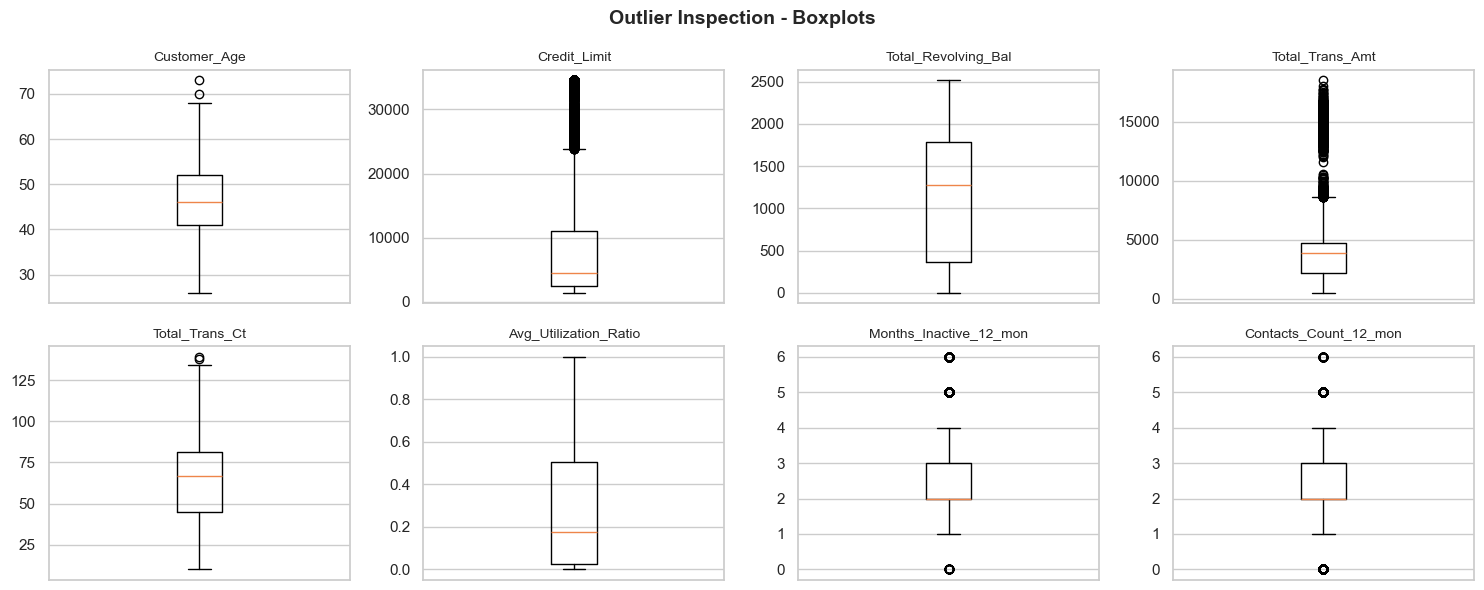

In [36]:
# Boxplots for visual outlier inspection
fig, subplot_axes = plt.subplots(2, 4, figsize=(15, 6))
subplot_axes = subplot_axes.flatten()
for index, col in enumerate(num_features_for_outliers):
    subplot_axes[index].boxplot(df[col], vert=True)
    subplot_axes[index].set_title(col, fontsize=10)
    subplot_axes[index].set_xticks([])
plt.suptitle('Outlier Inspection - Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/01_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

**Inference: Outliers**
- Credit_Limit and Total_Trans_Amt show the largest right tails with several high-value observations. These values appear plausible for credit card customers and are retained for further analysis.
- Avg_Utilization_Ratio contains several observations close to 1.0, indicating customers utilizing nearly all of their available credit. These values are valid business observations rather than apparent data errors.
- **Decision:** No outliers were removed at this stage. The detected values appear to represent genuine customer behaviour rather than data quality issues. Since the tree-based models (Random Forest, gradient boosting) are relatively robust to outliers, they are retained for modelling.

### 1.7 Encode Target Variable

ML models work on numbers, not strings. Encode `Attrition_Flag` to a binary `Churn` column: 0 = active customer, 1 = churned customer.

In [37]:
df['Churn'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

print("Target variable 'Churn' created.")
print("\nCLASS DISTRIBUTION")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].mean()*100:.2f}%")

Target variable 'Churn' created.

CLASS DISTRIBUTION
Churn
0    8500
1    1627
Name: count, dtype: int64

Churn rate: 16.07%


**Inference: Class Distribution**

- The dataset contains 8,500 active and 1,627 churned customers, resulting in an approximately `5.2:1` ratio of active to churned customers.
- A naive classifier predicting every customer as active would achieve approximately 83.9% accuracy, demonstrating that accuracy alone is not an appropriate evaluation metric.
- Model performance will therefore be evaluated primarily using PR-AUC (the appropriate metric under 16% class imbalance), with Recall and ROC-AUC as secondary.
- With a 16.1% churn rate, improving recall enables more at-risk customers to be identified for targeted retention efforts, making it a business-critical objective.

### 1.8 Data Quality Audit Summary

In [38]:
audit = pd.DataFrame({
    'Item': [
        'Naive Bayes leakage columns',
        'Missing values',
        'Duplicate rows',
        'Unknown categories (Education/Marital/Income)',
        'Logical sanity (impossible values)',
        'Target encoding',
        'Outliers'
    ],
    'Status': [
        '2 columns identified',
        'None',
        'None',
        'Investigated - kept as legitimate category',
        'All checks pass',
        'String target(needs binary encoding)',
        'Reviewed via IQR + boxplots'
    ],
    'Action Taken': [
        'Dropped both columns before any analysis',
        'No action required',
        'No action required',
        'Confirmed data quality before exploratory analysis',
        'No action required',
        "Created 'Churn' column: 0 = Existing, 1 = Attrited",
        'No removal(tree models handle outliers natively)'
    ]
})
audit

,Item,Status,Action Taken
0,Naive Bayes leakage columns,2 columns identified,Dropped both columns before any analysis
1,Missing values,None,No action required
2,Duplicate rows,None,No action required
3,Unknown categories (Education/Marital/Income),Investigated - kept as legitimate category,Confirmed data quality before exploratory anal...
4,Logical sanity (impossible values),All checks pass,No action required
5,Target encoding,String target(needs binary encoding),"Created 'Churn' column: 0 = Existing, 1 = Attr..."
6,Outliers,Reviewed via IQR + boxplots,No removal(tree models handle outliers natively)


---
## Section 2: Univariate EDA (Feature Distributions)

Before stratifying by churn, inspect each feature in isolation to understand its shape (skewness, multi-modality, zero-inflation).

### 2.1 Numeric Feature Distributions

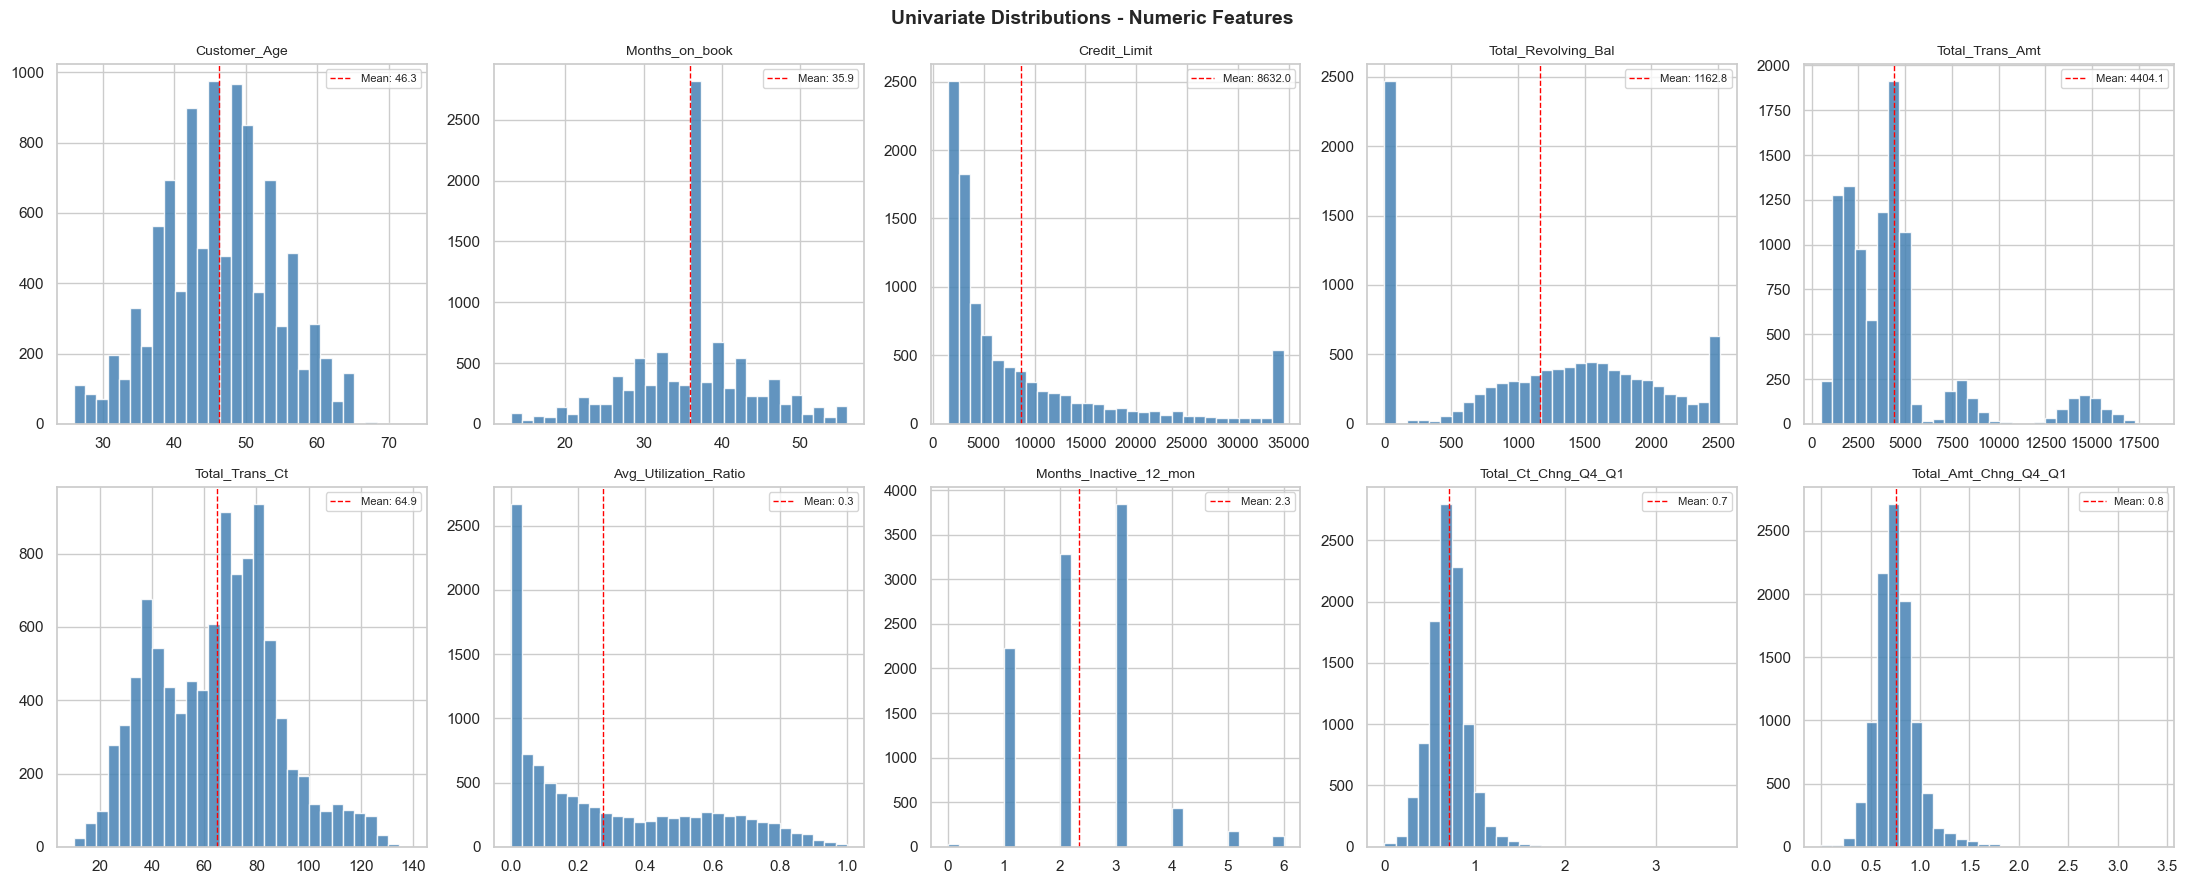

In [39]:
num_cols_dist = [
    'Customer_Age', 'Months_on_book', 'Credit_Limit',
    'Total_Revolving_Bal', 'Total_Trans_Amt', 'Total_Trans_Ct',
    'Avg_Utilization_Ratio', 'Months_Inactive_12_mon',
    'Total_Ct_Chng_Q4_Q1', 'Total_Amt_Chng_Q4_Q1'
]

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols_dist):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {df[col].mean():.1f}')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)
plt.suptitle('Univariate Distributions - Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/02_univariate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Inference: Numeric Features**
- `Total_Revolving_Bal` is heavily zero-inflated. A spike at 0 confirms the 24.4% transactor segment seen earlier
- `Credit_Limit` and `Total_Trans_Amt` are right-skewed (long high-value tail). Log-transform may help linear models in Notebook 03
- `Customer_Age` is roughly bell-shaped, centred at ~46
- `Total_Trans_Ct` shows a slightly right-skewed distribution. Transaction counts are concentrated in the middle of the range, while a relatively small number of customers exhibit very high transaction frequencies.
- `Avg_Utilization_Ratio` is highly right-skewed with many customers exhibiting very low credit utilization, while a smaller group utilizes a substantial proportion of their available credit.
- `Months_Inactive_12_mon` is a discrete variable concentrated around 2.3 inactive months, with relatively few customers remaining inactive for extended periods.
- `Total_Ct_Chng_Q4_Q1` and `Total_Amt_Chng_Q4_Q1` are centered near 1.0, suggesting stable quarter-over-quarter behavior for most customers, while lower values identify customers with notable declines in transaction activity that merit further investigation during churn analysis

### 2.2 Categorical Feature Counts

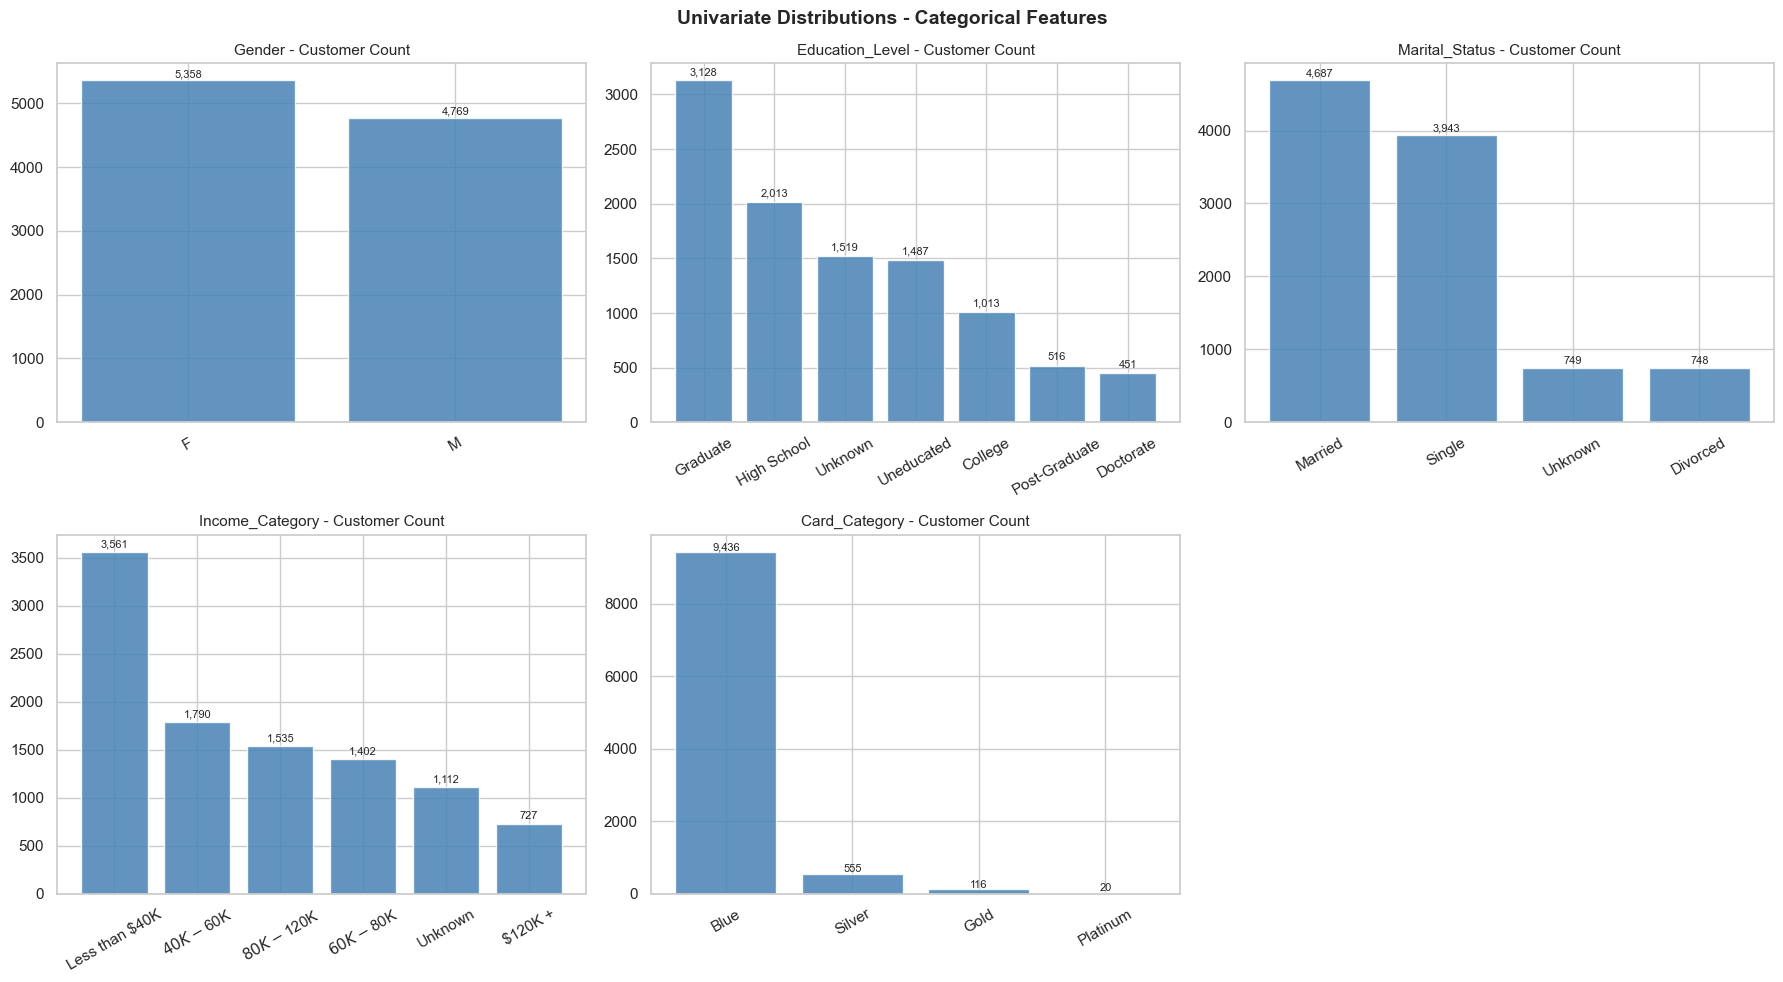

In [40]:
cat_cols = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', alpha=0.85)
    axes[i].set_title(f'{col} - Customer Count', fontsize=11)
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 50, f'{v:,}', ha='center', fontsize=8)
axes[-1].set_visible(False)
plt.suptitle('Univariate Distributions - Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/03_categorical_counts.png', dpi=150, bbox_inches='tight')
plt.show()

**Inference: Categorical Distributions**
- `Card_Category` is dominated by Blue (93%). while Gold has 116 and Platinum 20 represent very small segments. Churn rate calculated for these smaller segments should be interpreted cautiously due to the limited sample size. 
- `Gender` is roughly balanced (M/F), reducing the likelihood of strong gender imbalance in subsequent analyses.
- `Income_Category` and `Education_Level` contain a notable proportion of "Unknown" values. As this data quality issue was identified earlier, these categories should be interpreted with caution in downstream analyses.
- `Marital_Status` is dominated by Married and Single

---
## Section 3: Bivariate EDA (Features vs Churn)

### 3.1 Target Class Distribution

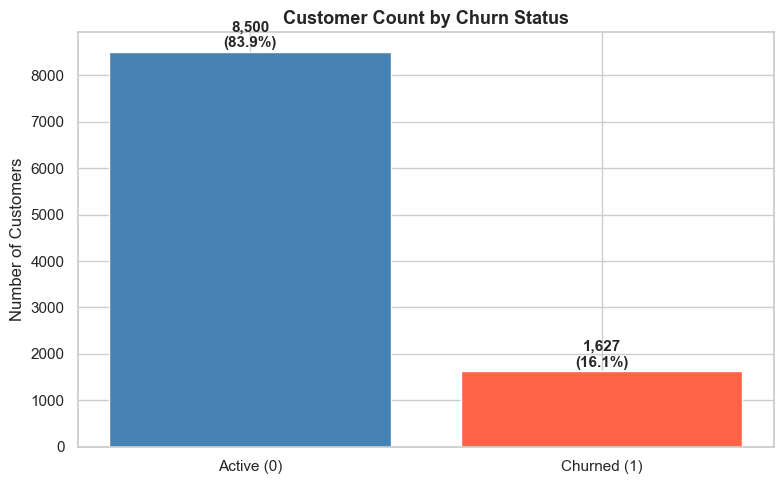


Class imbalance ratio: 83.9% Active vs 16.1% Churned
NOTE: Class imbalance present, accuracy alone is misleading. PR-AUC is primary evaluation metric.


In [41]:
churn_counts = df['Churn'].value_counts().sort_index()
churn_pct = df['Churn'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Active (0)', 'Churned (1)'], churn_counts, color=['steelblue', 'tomato'])
ax.set_title('Customer Count by Churn Status', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Customers')

for i, (count, pct) in enumerate(zip(churn_counts, churn_pct)):
    ax.text(i, count + 100, f'{count:,}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/charts/04_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass imbalance ratio: {churn_pct[0]:.1f}% Active vs {churn_pct[1]:.1f}% Churned")
print("NOTE: Class imbalance present, accuracy alone is misleading. PR-AUC is primary evaluation metric.")

**Inference: Target Class Distribution**

- The dataset contains 10,127 customers, of which 8,500 (83.9%) are active and 1,627 (16.1%) have churned.
- Customer churn is a minority outcome, with approximately one in six customers leaving the bank during the observation period.
- This class distribution should be considered when building predictive models, as performance metrics beyond overall accuracy may be required.

### 3.2 Churn Rate by Categorical Features (with Sample Sizes)

In [42]:
# Compute churn rate AND sample size per category

MIN_CUSTOMERS = 50

def churn_by_category(df, col):
    g = (
        df.groupby(col)['Churn']
          .agg(['count', 'mean'])
          .sort_values('mean', ascending=False)
    )

    g.columns = ['Customers', 'Churn_Rate']
    g['Churn_Rate'] = (g['Churn_Rate'] * 100).round(1)

    return g[g['Customers'] >= MIN_CUSTOMERS]


print(f"CHURN RATE BY CATEGORY (showing groups with ≥ {MIN_CUSTOMERS} customers)")

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(churn_by_category(df, col))

CHURN RATE BY CATEGORY (showing groups with ≥ 50 customers)

--- Gender ---
        Customers  Churn_Rate
Gender                       
F            5358        17.4
M            4769        14.6

--- Education_Level ---
                 Customers  Churn_Rate
Education_Level                       
Doctorate              451        21.1
Post-Graduate          516        17.8
Unknown               1519        16.9
Uneducated            1487        15.9
Graduate              3128        15.6
College               1013        15.2
High School           2013        15.2

--- Marital_Status ---
                Customers  Churn_Rate
Marital_Status                       
Unknown               749        17.2
Single               3943        16.9
Divorced              748        16.2
Married              4687        15.1

--- Income_Category ---
                 Customers  Churn_Rate
Income_Category                       
$120K +                727        17.3
Less than $40K        3561        

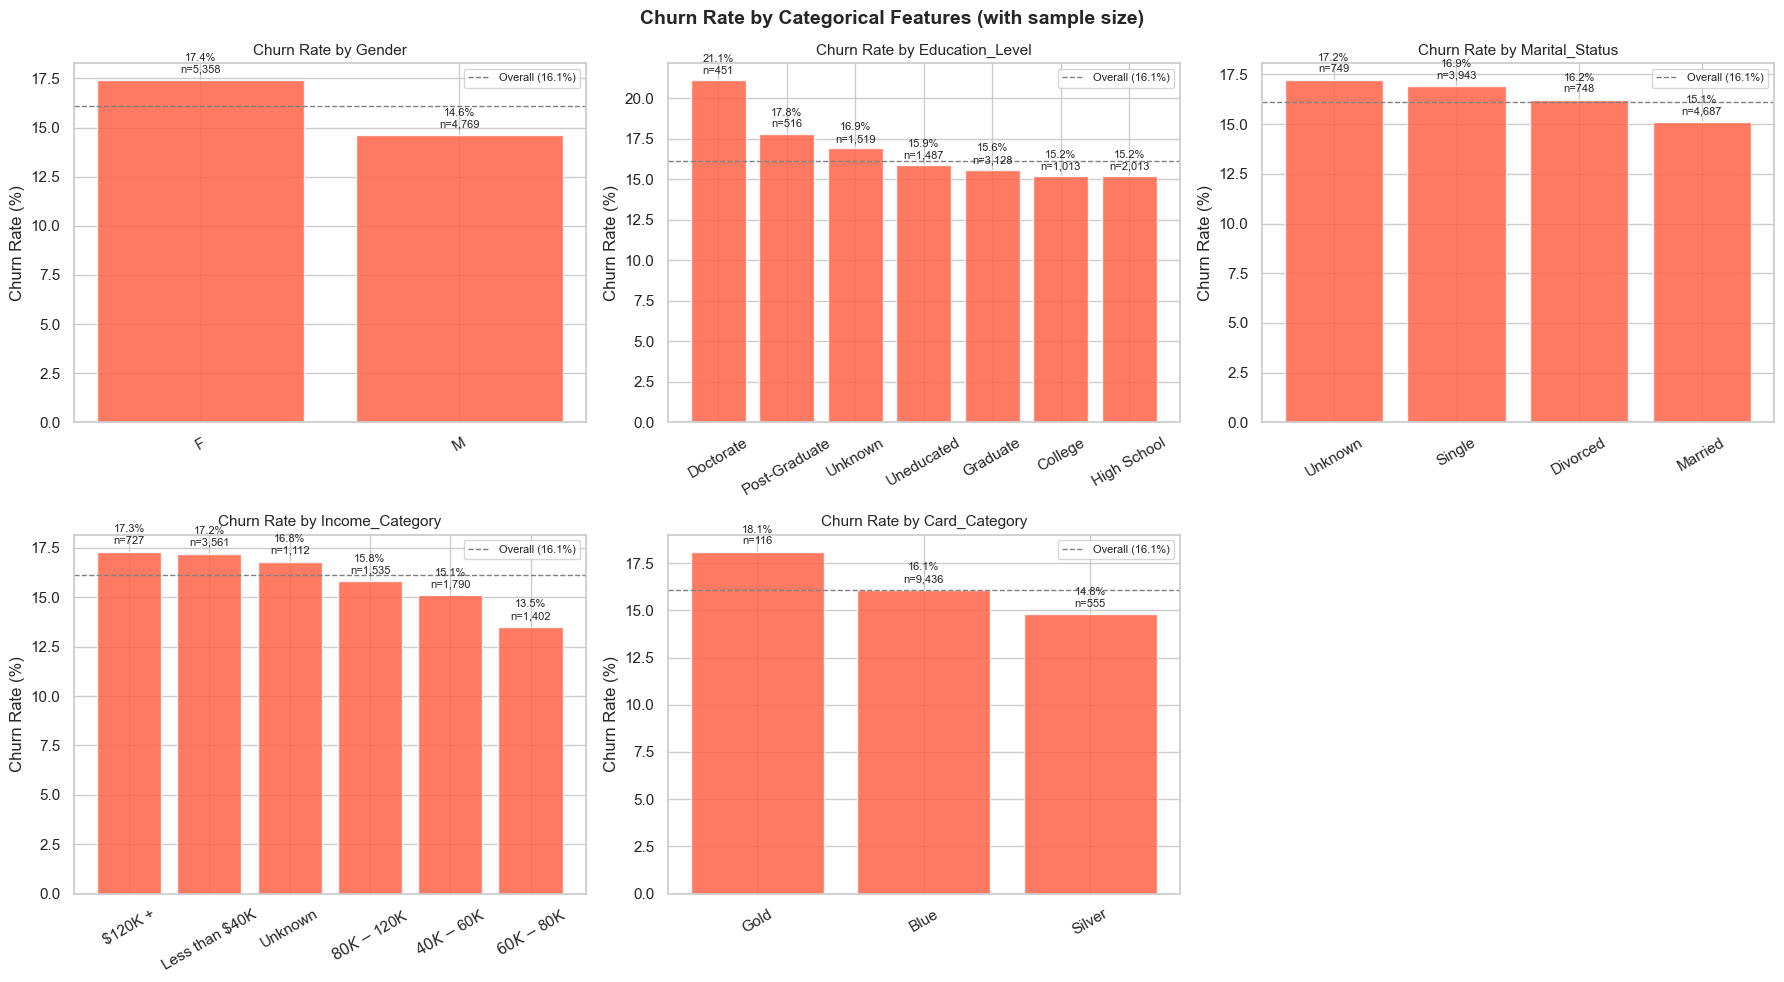

In [43]:
# Plot churn rate by category with sample size annotation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    g = churn_by_category(df, col)
    bars = axes[i].bar(g.index.astype(str), g['Churn_Rate'], color='tomato', alpha=0.85)
    axes[i].set_title(f'Churn Rate by {col}', fontsize=11)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(16.1, color='gray', linestyle='--', linewidth=1, label='Overall (16.1%)')
    axes[i].legend(fontsize=8)
    for j, (rate, n) in enumerate(zip(g['Churn_Rate'], g['Customers'])):
        label = f'{rate:.1f}%\nn={n:,}'
        axes[i].text(j, rate + 0.4, label, ha='center', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Churn Rate by Categorical Features (with sample size)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/05_churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

**Inference: Categorical vs Churn**

- **Card_Category:** **Blue cards** represent the vast majority of customers (9,436; ~93%). **Gold** customers show the highest observed churn rate (18.1%), while **Silver** has the lowest (14.8%). Interpretation should be cautious because Gold has a relatively small sample (116 customers), and Platinum (20 customers) was excluded from the analysis due to insufficient observations.
- **Gender:** Female customers have a higher observed churn rate than male customers (17.4% vs. 14.6%). Both groups have large sample sizes (>4,500 customers), making this difference suitable for further investigation.
- **Income_Category:** Churn does not follow a monotonic trend across income groups. The <$40K and $120K+ segments have the highest observed churn rates (~17%), while the $60K–$80K segment has the lowest observed churn rate (13.5%).
- **Marital_Status:** Churn rates vary only modestly across marital status groups. The Unknown category has the highest observed churn rate (17.2%), while Married customers have the lowest (15.1%). The elevated churn among the Unknown group is consistent with the earlier observation that missing values may contain useful information.
- **Education_Level:** Doctorate customers have the highest observed churn rate (21.1%), while High School and College customers have the lowest (15.2%). Although the Doctorate group is smaller than other education segments (451 customers), its sample size remains substantially larger than categories excluded from analysis.

### 3.3 Churn Rate by Binned Numeric Features

Categorical churn rates only tell part of the story. The strongest churn signals in this dataset come from numeric behavioural features. Binning them into quartiles (or fewer bins where values are heavily tied) reveals the magnitude of the churn gap clearly. Two features, Months_Inactive_12_mon and Contacts_Count_12_mon, are low-cardinality integer counts with many repeated values, so qcut could not split them into four equal groups and fell back to three bins. Months_Inactive_12_mon is additionally shown at its raw per-month level in the cell below, because its range is small enough that each exact month count is directly interpretable and more informative than a three-bin summary.

=== CHURN RATE BY BIN (numeric features) ===

--- Total_Trans_Ct (quartiles) ---
               count  Churn_Rate
_bin                            
(9.999, 45.0]   2611       37.07
(45.0, 67.0]    2512       20.46
(67.0, 81.0]    2662        4.47
(81.0, 139.0]   2342        1.11
Highest-risk bin (9.999, 45.0] (37.07%) vs lowest-risk bin (81.0, 139.0] (1.11%): 33.4x

--- Total_Trans_Amt (quartiles) ---
                   count  Churn_Rate
_bin                                
(509.999, 2155.5]   2532       24.41
(2155.5, 3899.0]    2532       27.53
(3899.0, 4741.0]    2534        0.87
(4741.0, 18484.0]   2529       11.47
Highest-risk bin (2155.5, 3899.0] (27.53%) vs lowest-risk bin (3899.0, 4741.0] (0.87%): 31.6x

--- Total_Revolving_Bal (quartiles) ---
                  count  Churn_Rate
_bin                               
(-0.001, 359.0]    2532       37.72
(359.0, 1276.0]    2532       10.31
(1276.0, 1784.0]   2535        4.34
(1784.0, 2517.0]   2528       11.91
Highest-risk bin (-0.00

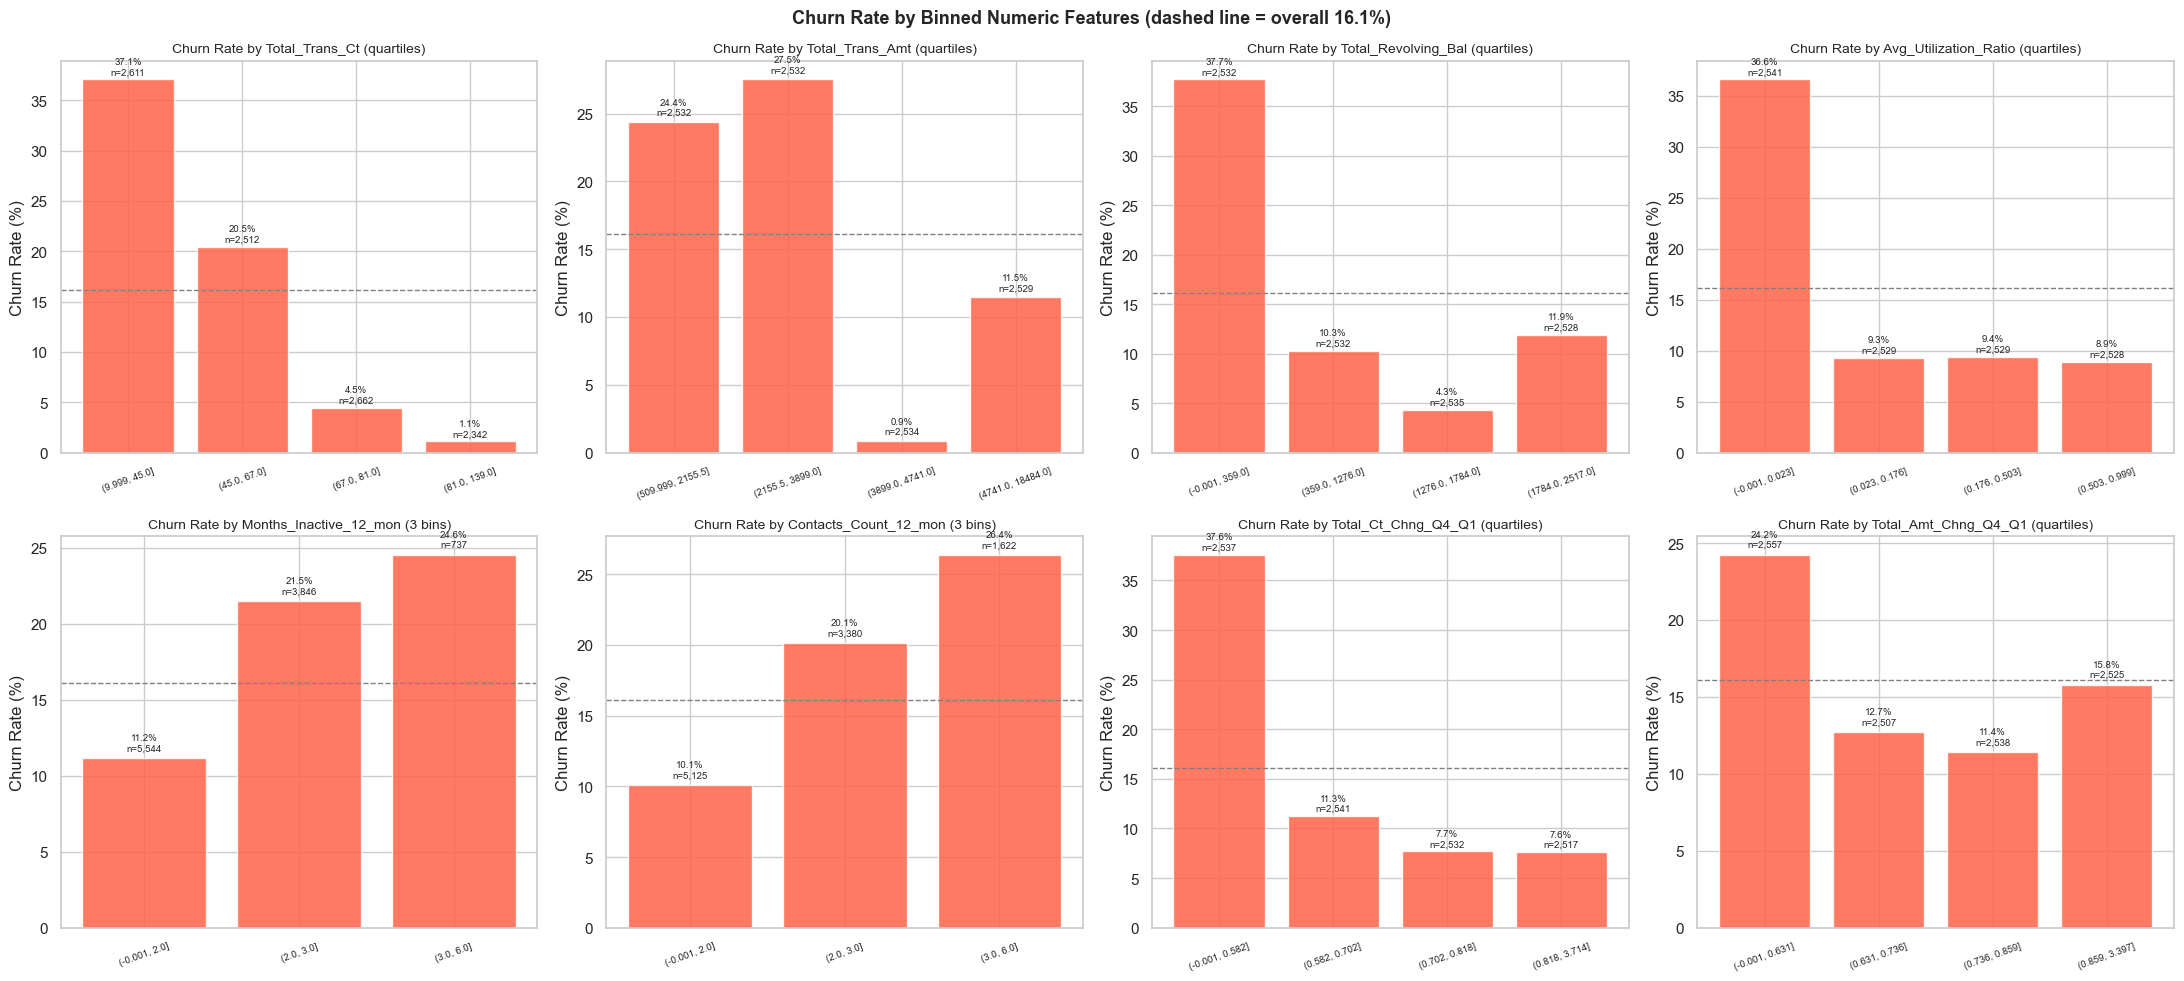

In [44]:
numeric_to_bin = [
    'Total_Trans_Ct',
    'Total_Trans_Amt',
    'Total_Revolving_Bal',
    'Avg_Utilization_Ratio',
    'Months_Inactive_12_mon',
    'Contacts_Count_12_mon',
    'Total_Ct_Chng_Q4_Q1',
    'Total_Amt_Chng_Q4_Q1'
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

print("=== CHURN RATE BY BIN (numeric features) ===")

for i in range(len(numeric_to_bin)):
    col = numeric_to_bin[i]

    # Try quartile bins first. Some columns have too many repeated values
    # for pandas to split into 4 equal groups, so we fall back to equal-width bins.
    try:
        temp_bins = pd.qcut(df[col], q=4, duplicates='drop')
    except ValueError:
        temp_bins = pd.cut(df[col], bins=4)

    df['_bin'] = temp_bins

    bin_stats = df.groupby('_bin')['Churn'].agg(['count', 'mean'])
    bin_stats['Churn_Rate'] = (bin_stats['mean'] * 100).round(2)

    n_bins = len(bin_stats)
    bin_type = "quartiles" if n_bins == 4 else f"{n_bins} bins"

    print(f"\n--- {col} ({bin_type}) ---")
    print(bin_stats[['count', 'Churn_Rate']])

    # Compare the highest-risk bin to the lowest-risk bin, wherever they fall.
    # Bottom-vs-top only measures the real spread if churn happens to be
    # monotonic. For non-monotonic features (dip-then-rise patterns), the
    # true highest and lowest risk bins can be anywhere in the table.
    max_rate = bin_stats['Churn_Rate'].max()
    min_rate = bin_stats['Churn_Rate'].min()
    max_bin = bin_stats['Churn_Rate'].idxmax()
    min_bin = bin_stats['Churn_Rate'].idxmin()

    if min_rate > 0:
        ratio = max_rate / min_rate
        print(f"Highest-risk bin {max_bin} ({max_rate}%) vs lowest-risk bin "
              f"{min_bin} ({min_rate}%): {ratio:.1f}x")

    # Plot this feature's bar chart in its subplot position
    ax = axes[i]
    ax.bar(range(len(bin_stats)), bin_stats['Churn_Rate'], color='tomato', alpha=0.85)
    ax.set_xticks(range(len(bin_stats)))
    ax.set_xticklabels([str(idx) for idx in bin_stats.index], rotation=20, fontsize=7)
    ax.set_title(f'Churn Rate by {col} ({bin_type})', fontsize=10)
    ax.set_ylabel('Churn Rate (%)')
    ax.axhline(16.1, color='gray', linestyle='--', linewidth=1)

    # Label each bar with its rate and sample size
    for j in range(len(bin_stats)):
        rate = bin_stats['Churn_Rate'].iloc[j]
        n = bin_stats['count'].iloc[j]
        ax.text(j, rate + 0.5, f'{rate:.1f}%\nn={n:,}', ha='center', fontsize=7)

    # Remove the temporary bin column before moving to the next feature
    df.drop(columns=['_bin'], inplace=True)

plt.suptitle('Churn Rate by Binned Numeric Features (dashed line = overall 16.1%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/06_churn_by_binned_numeric.png', dpi=150, bbox_inches='tight')
plt.show()

##### Raw per-month churn rate for `Months_Inactive_12_mon`. The binned version above compresses this into three groups; the table below keeps every month value separate to expose the non-linear shape that binning hides.

In [45]:
df.groupby('Months_Inactive_12_mon')['Churn'].agg(['count', 'mean'])

,count,mean
Months_Inactive_12_mon,,
0,29,0.517241
1,2233,0.044783
2,3282,0.153870
3,3846,0.214769
4,435,0.298851
5,178,0.179775
6,124,0.153226


**Inference: Binned Numeric vs Churn (headline finding of the EDA)**
All churn rates below are measured against an overall baseline of 16.1%. Ratios compare the highest-risk bin to the lowest-risk bin, wherever each falls, because several features are non-monotonic and a simple bottom-vs-top comparison would misstate the true spread.

- `Total_Trans_Ct` is the strongest single churn signal in the dataset. Churn falls monotonically across quartiles (37.1%, 20.5%, 4.5%, 1.1%), a 33.4x gap between the least and most active groups. Business impact: transaction count is the earliest and cleanest usage-based flag available for retention targeting. A customer sliding into the lowest activity quartile is a high-priority intervention candidate well before slower signals like multi-month inactivity would surface them.
- `Total_Trans_Amt` shows a nearly identical risk spread (31.6x) but a non-monotonic shape. Churn is highest in the second quartile (27.5%) and first quartile (24.4%), collapses in the third (0.9%), and partially rebounds in the fourth (11.5%). Business impact: a naive "low spend equals high risk" rule would be wrong at both ends. Moderately-low spenders are as risky as the lowest spenders, and the highest spenders are not fully safe. Any spend-based targeting must treat the safe zone as the mid-high range specifically, not "more spend is better."
- `Total_Revolving_Bal` ranges from 37.7% churn at near-zero balance down to 4.3% mid-range, then back up to 11.9% at the highest balances, an 8.7x spread. Business impact: the near-zero-balance group is a distinct disengaged segment (customers who pay in full or barely use the card), not a financial-stress segment. Retention messaging built around debt management would not land here; this group needs an engagement or usage-incentive approach instead. This connects directly to the Transactor vs Revolver split explored in Section 3.4.
- `Avg_Utilization_Ratio` concentrates churn almost entirely in the near-zero utilization bin (36.6%); the remaining three quartiles cluster tightly near 9%, giving a 4.1x spread driven by a single cliff rather than a gradient. Business impact: utilization is useful here as a binary "effectively not using the card" flag, not as a graded risk score. Once a customer is above near-zero usage, utilization adds little further discrimination, so effort is better spent detecting the drop to near-zero than tracking utilization changes higher up.
- `Total_Ct_Chng_Q4_Q1` falls from 37.6% churn for customers with the sharpest quarter-over-quarter drop in transaction count to 7.6% for those with stable or rising activity, a 4.9x spread. Business impact: this is a trend signal, not a snapshot. It can flag a deteriorating customer whose absolute activity still looks acceptable, catching risk earlier than any single-point-in-time level feature. It is the strongest of the two change-based features and belongs in any early-warning rule.
- `Total_Amt_Chng_Q4_Q1` is the noisier change feature (24.3%, 12.7%, 11.4%, 15.8%), with churn ticking back up in the top quartile, a 2.1x spread. Business impact: weaker and less consistent than the count-based trend above. Use it to corroborate Total_Ct_Chng_Q4_Q1, not as a standalone targeting driver.
- `Contacts_Count_12_mon` (3 bins, not quartiles) rises monotonically with contact frequency: 10.1%, 20.2%, 26.4%, a 2.6x spread. Business impact: contact history is visible to frontline staff in real time, unlike features that need a full 12-month window to compute. This makes it usable as a live outreach trigger rather than a purely retrospective one. Direction of causation is unresolved: heavy contact may signal dissatisfaction, or the same underlying problem may drive both.
- `Months_Inactive_12_mon` is non-linear at the raw month level. Churn rises from 1 to 4 months inactive (4.5%, 15.4%, 21.5%, 29.9%), then declines at 5 and 6 months (18.0%, 15.3%). The 0-month group is higher still (51.7%) but on only 29 customers, too small to rely on. Business impact: targeting only the longest-inactive customers would miss the true reliable risk peak around 4 months and would misallocate effort toward the 5-to-6-month group, which is likely a more entrenched, lower-risk population that has already stayed without churning. The actionable threshold is roughly 3 to 4 months of inactivity, not "the longer the worse."


**Cross-feature pattern worth noting:** three spend-and-balance features (`Total_Trans_Amt`, `Total_Revolving_Bal`, `Total_Amt_Chng_Q4_Q1`) share the same dip-then-rise shape, with risk elevated at both the low and high ends and safest in the middle. This recurring non-monotonicity is itself a finding: single-threshold targeting rules will systematically misclassify one tail, and any model using these features should not assume a linear relationship with churn.

### 3.4 Transactor vs Revolver Comparison

Section 1.5 noted 24.4% of customers carry zero revolving balance. These are **transactors** (carry no revolving balance at this snapshot). Behaviourally, they are distinct from **revolvers** (carry balance and pay interest). Their churn dynamics differ.

=== TRANSACTOR vs REVOLVER ===
               Customers  Churn_Rate
Customer_Type                       
Revolver            7657        9.59
Transactor          2470       36.15

Overall churn rate: 16.07%


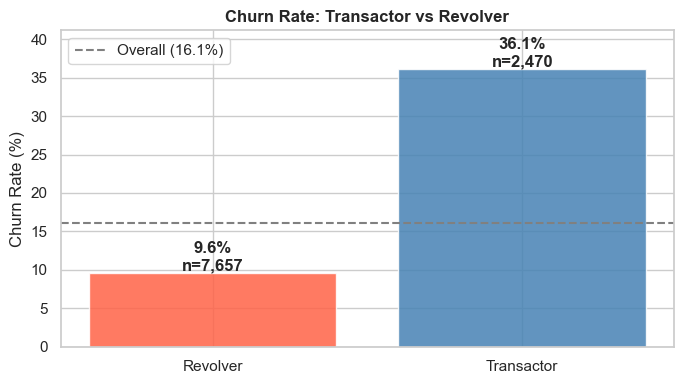

In [46]:
df['Customer_Type'] = np.where(df['Total_Revolving_Bal'] == 0, 'Transactor', 'Revolver')

type_stats = df.groupby('Customer_Type')['Churn'].agg(['count', 'mean'])
type_stats.columns = ['Customers', 'Churn_Rate']
type_stats['Churn_Rate'] = (type_stats['Churn_Rate'] * 100).round(2)

print("=== TRANSACTOR vs REVOLVER ===")
print(type_stats)
print(f"\nOverall churn rate: {df['Churn'].mean()*100:.2f}%")

# Quick visual
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(type_stats.index, type_stats['Churn_Rate'], color=['tomato', 'steelblue'], alpha=0.85)

ax.set_ylim(0, type_stats['Churn_Rate'].max() + 5)

ax.axhline(16.1, color='gray', linestyle='--', label='Overall (16.1%)')
ax.set_title('Churn Rate: Transactor vs Revolver', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
for i, (rate, n) in enumerate(zip(type_stats['Churn_Rate'], type_stats['Customers'])):
    ax.text(i, rate + 0.3, f'{rate:.1f}%\nn={n:,}', ha='center', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/charts/07_transactor_vs_revolver.png', dpi=150, bbox_inches='tight')
plt.show()

# Drop the helper column - not carried into modelling without re-evaluation
df.drop(columns=['Customer_Type'], inplace=True)

**Inference: Transactor vs Revolver**

- Splitting customers by a single binary rule, whether they carry any revolving balance, produces a sharp churn gap. Transactors (customers carrying zero revolving balance at this snapshot) churn at 36.15%, while revolvers churn at 9.59%, a 3.8x difference. Transactors are roughly a quarter of the customer base (2,470 of 10,127) yet churn at more than double the overall 16.1% rate.  
- This is the largest churn gap produced by any single yes/no business rule in this EDA. It does not exceed the quartile-based gaps in Section 3.3 (Total_Trans_Ct at 33.4x, Total_Trans_Amt at 31.6x), which are larger but require binning a continuous feature into four groups. The value of the transactor split is its simplicity: it separates a high-risk quarter of the book with one interpretable question, "do you pay interest or not?"
- **Business impact**: transactors are a large, clearly defined, high-churn segment that a retention team can action immediately without any model. Because they carry no revolving balance, standard interest-based or debt-management retention offers are irrelevant to them; retention here depends on engagement, rewards, or transactional value rather than credit terms. A quarter of customers churning at over twice the baseline is a concentrated, addressable risk.
- **Action for Notebook 02:** create the binary feature `is_transactor = (Total_Revolving_Bal == 0)` and test it. Caveat: this feature is derived directly from `Total_Revolving_Bal` and is likely to overlap with `Avg_Utilization_Ratio`, so its unique predictive contribution should be checked against those features rather than assumed. A large univariate gap justifies testing the feature, not concluding in advance that it will rank among the most predictive. (is_transactor is renamed to zero_revolving_balance in notebook02 ).

### 3.5 Numeric Feature Distributions Stratified by Churn

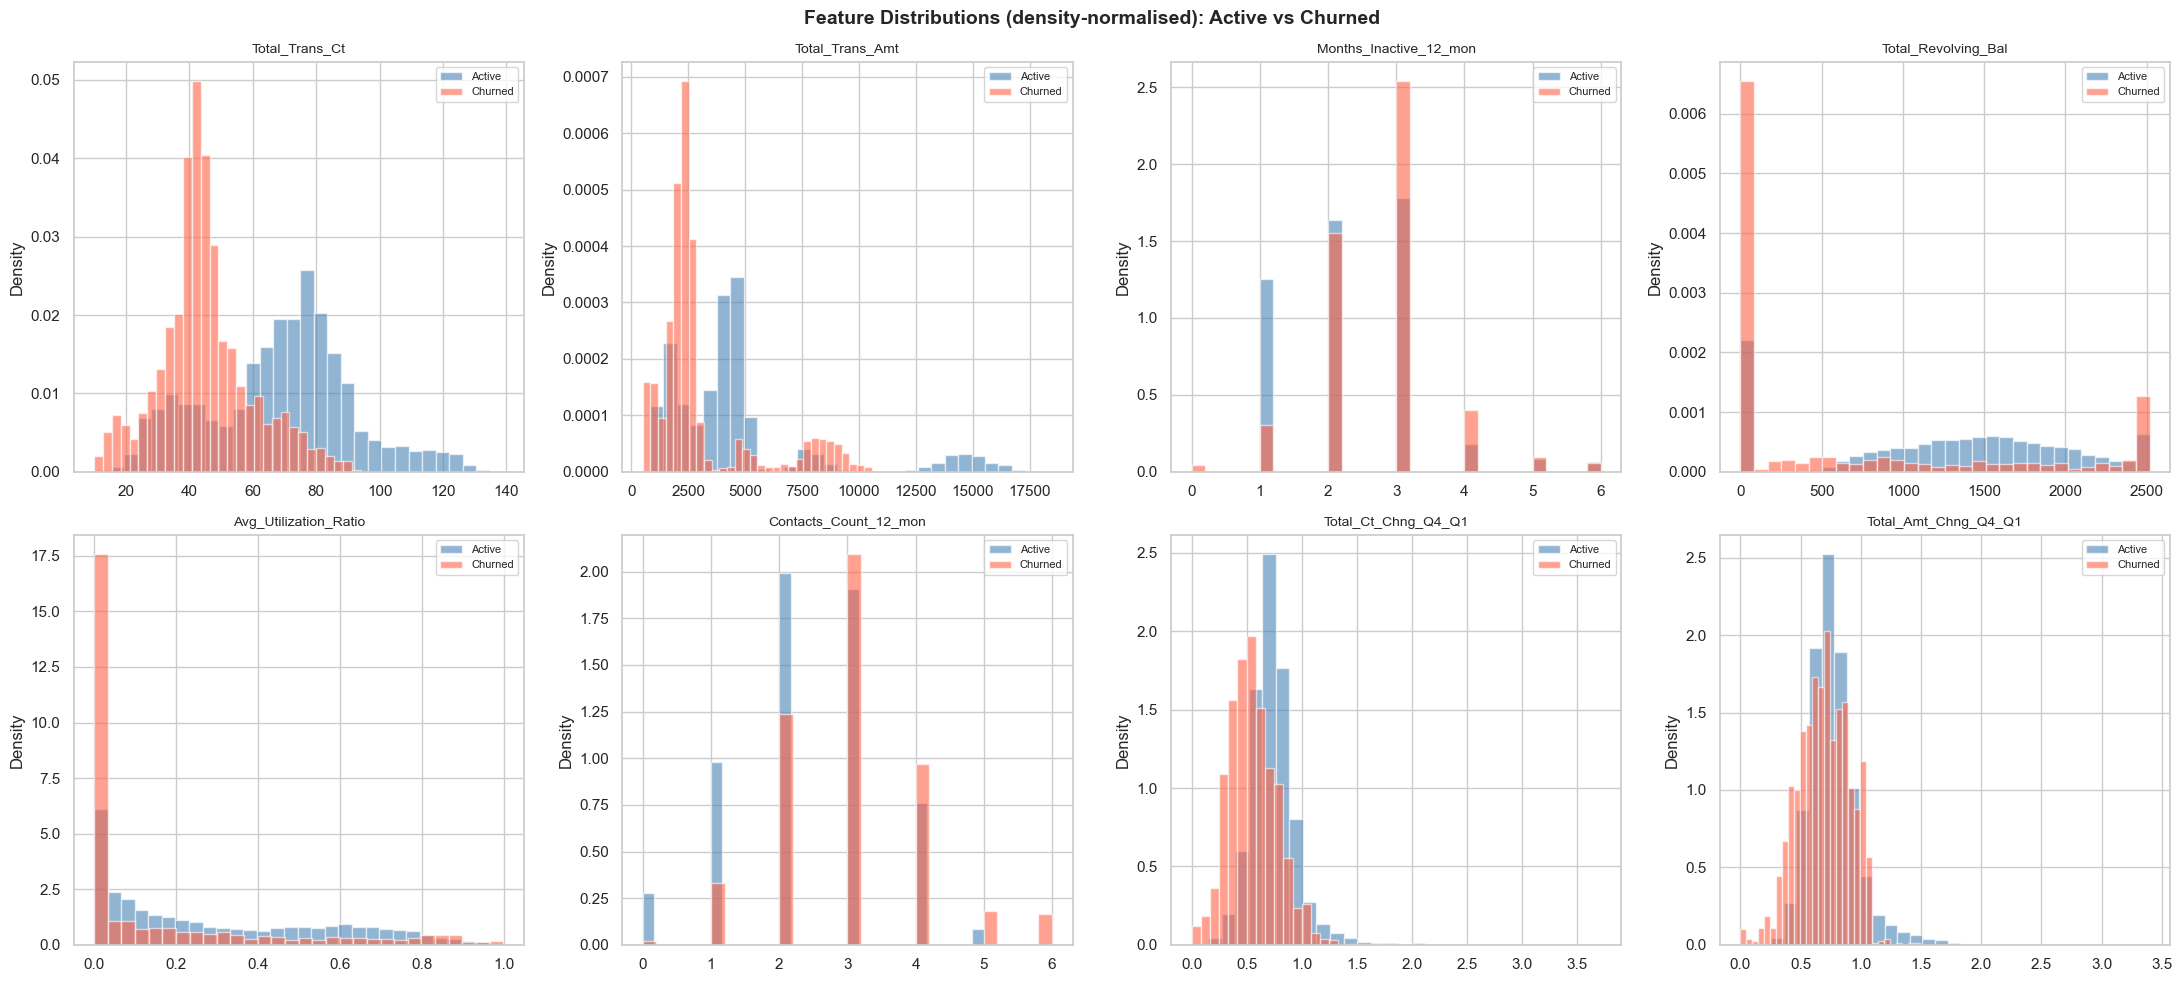

In [47]:
num_cols_strat = [
    'Total_Trans_Ct', 'Total_Trans_Amt',
    'Months_Inactive_12_mon', 'Total_Revolving_Bal',
    'Avg_Utilization_Ratio', 'Contacts_Count_12_mon',
    'Total_Ct_Chng_Q4_Q1', 'Total_Amt_Chng_Q4_Q1'
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols_strat):
    # density=True normalises both classes so the smaller (Churned) is visible
    axes[i].hist(df[df['Churn'] == 0][col], bins=30, alpha=0.6, label='Active',
                 color='steelblue', density=True)
    axes[i].hist(df[df['Churn'] == 1][col], bins=30, alpha=0.6, label='Churned',
                 color='tomato', density=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions (density-normalised): Active vs Churned', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/08_feature_distributions_stratified.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
print("=== MEAN COMPARISON: CHURNED vs ACTIVE ===")
comparison = df.groupby('Churn')[num_cols_strat].mean().round(2)
comparison.index = ['Active', 'Churned']
comparison_T = comparison.T
comparison_T['Gap_Pct'] = ((comparison_T['Churned'] - comparison_T['Active']) / comparison_T['Active'] * 100).round(1)
print(comparison_T)

=== MEAN COMPARISON: CHURNED vs ACTIVE ===
                         Active  Churned  Gap_Pct
Total_Trans_Ct            68.67    44.93    -34.6
Total_Trans_Amt         4654.66  3095.03    -33.5
Months_Inactive_12_mon     2.27     2.69     18.5
Total_Revolving_Bal     1256.60   672.82    -46.5
Avg_Utilization_Ratio      0.30     0.16    -46.7
Contacts_Count_12_mon      2.36     2.97     25.8
Total_Ct_Chng_Q4_Q1        0.74     0.55    -25.7
Total_Amt_Chng_Q4_Q1       0.77     0.69    -10.4


**Inference: Distributions Stratified by Churn**
The mean comparison confirms, at the level of averages, the same signals identified through binning in Section 3.3, and adds a directional summary of how each feature separates the two groups.

- The largest average gaps are in engagement and usage depth, not demographics. Churned customers average 46.7% lower utilization and 46.5% lower revolving balance, 34.6% fewer transactions, and 33.5% lower transaction amount than active customers. These four features separate the groups most strongly and all point the same way: churned customers were less engaged with the card.
- Two features move in the opposite direction, higher for churned customers: months inactive (up 18.5%) and contact count (up 25.8%). This is consistent with Section 3.3, more inactivity and more support contact are both associated with higher churn.
The change features (Total_Ct_Chng_Q4_Q1 down 25.7%, Total_Amt_Chng_Q4_Q1 down 10.4%) show churned customers had steeper declines in activity, with the count-based change again the stronger of the two, consistent with Section 3.3.
- **Business impact:** the features that best distinguish churners are all behavioural and card-usage based, not demographic. This means churn risk is driven by how customers use the product, which the business can influence, rather than by who they are, which it cannot. Retention effort is best directed at usage and engagement signals.
- **Caveat:** these are univariate mean differences, not independent effects. Several of these features are correlated with each other (for example utilization, revolving balance, and transaction volume), so a large gap here does not establish that a feature adds independent predictive value. The correlation structure is examined in Section 3.6, and independent contribution can only be assessed during modelling.


**Note on the histograms:** the density-normalised view is informative for the continuous features, but Months_Inactive_12_mon and Contacts_Count_12_mon are low-cardinality integer counts, so their 30-bin density curves should be read as approximate; the mean-gap table above is the more reliable summary for those two.

### 3.6 Correlation Heatmap

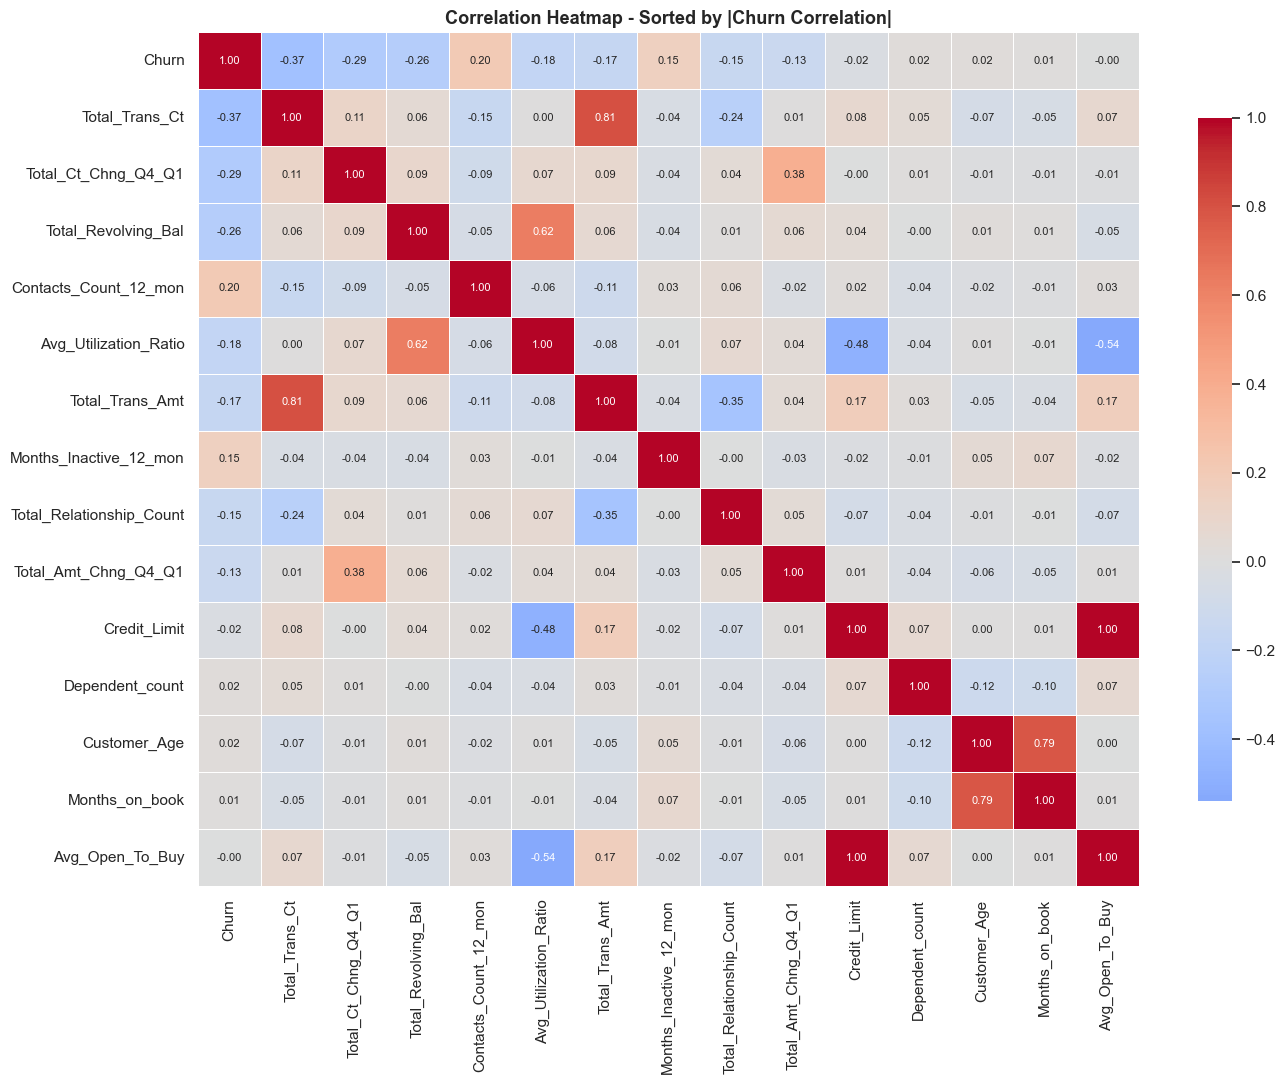


=== TOP CORRELATIONS WITH CHURN (absolute) ===
Total_Trans_Ct              0.371
Total_Ct_Chng_Q4_Q1         0.290
Total_Revolving_Bal         0.263
Contacts_Count_12_mon       0.204
Avg_Utilization_Ratio       0.178
Total_Trans_Amt             0.169
Months_Inactive_12_mon      0.152
Total_Relationship_Count    0.150
Total_Amt_Chng_Q4_Q1        0.131
Credit_Limit                0.024
Name: Churn, dtype: float64


In [49]:
# Exclude ID and helper columns
cols_to_exclude = ['CLIENTNUM', 'Has_Unknown']
numeric_df = df.select_dtypes(include=np.number).drop(columns=cols_to_exclude, errors='ignore')

corr_matrix = numeric_df.corr()

# Sort by absolute correlation with Churn - most important features appear top-left
churn_corr = corr_matrix['Churn'].abs().sort_values(ascending=False)
ordered_cols = churn_corr.index.tolist()
corr_matrix = corr_matrix.loc[ordered_cols, ordered_cols]

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap - Sorted by |Churn Correlation|', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/09_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with Churn
print("\n=== TOP CORRELATIONS WITH CHURN (absolute) ===")
top_corr = numeric_df.corr()['Churn'].drop('Churn').abs().sort_values(ascending=False).head(10)
print(top_corr.round(3))

**Inference: Correlation with Churn**

Correlation here measures linear association with churn only. It is useful for ranking roughly monotonic features and for spotting redundancy between features, but it under-reads features whose relationship with churn is non-linear, which matters below.

- **Strongest linear correlations with churn:** Total_Trans_Ct (0.37) is clearly the top signal, followed by Total_Ct_Chng_Q4_Q1 (0.29), Total_Revolving_Bal (0.26), Contacts_Count_12_mon (0.20), and Avg_Utilization_Ratio (0.18). Directionally (from the Section 3.5 mean comparison), churn is associated with lower transaction count, a steeper quarter-over-quarter decline in transactions, lower revolving balance, lower utilization, and a higher number of support contacts.
- `Total_Trans_Amt` is the notable exception. Its linear correlation is only 0.17, mid-pack, yet Section 3.3 showed it has the second-largest quartile churn gap in the dataset (31.6x). The reason is that its relationship with churn is non-monotonic (high risk at both low and moderately-low spend, low risk in the middle, partial rebound at the top), and correlation only captures the linear part of that shape. This is a caution for feature selection: ranking features by correlation alone would wrongly demote Total_Trans_Amt. It should be retained and tested despite its modest correlation.

- **Redundancy flag:** `Credit_Limit` and `Avg_Open_To_Buy` are near-perfectly correlated, because `Avg_Open_To_Buy` = `Credit_Limit` -  `Total_Revolving_Bal` by construction. Only one should be kept for any model to avoid multicollinearity. `Avg_Utilization_Ratio = Total_Revolving_Bal / Credit_Limit` so utilization, revolving balance, and the transactor split are three views of one underlying signal, not three independent findings.

- **Weak signals:** Customer_Age and Months_on_book show near-zero correlation with churn, and Credit_Limit itself is very weak (0.02). Age, tenure, and raw credit limit do not linearly separate churners in this dataset. This is consistent with the earlier finding that churn is driven by behaviour rather than demographics or account size.

- **Caveat:** these are pairwise correlations, not independent effects, and several of the behavioural features are correlated with each other. A feature's correlation with churn does not establish its unique predictive contribution; that can only be assessed during modelling with the correlated features considered together.




**Notebook 02 (Feature Engineering) handoff:**
1. Drop Avg_Open_To_Buy (redundant with Credit_Limit)
2. Create is_transactor binary feature from Total_Revolving_Bal == 0
3. Create has_unknown_demographic binary feature
4. Consider interaction: Total_Trans_Ct x Months_Inactive_12_mon (activity-decay composite)
5. Do not log-transform in the shared CSV. A log is invisible to tree models and would dilute feature importance. NB03 applies log(Total_Trans_Amt) via FunctionTransformer inside the logistic-regression pipeline only.
6. Retain Total_Trans_Amt despite low linear correlation, its predictive value is non-linear and will be missed by correlation-based selection

---
---
## Key Findings from EDA

**Data Quality**
- 10,127 customers, 21 columns after dropping 2 Naive Bayes columns. Of these, 19 are candidate predictors,plus the ID column and the target.
- No missing values, no duplicate rows, no logically impossible values (utilization stayed within [0, 1]; no negative transaction amounts; tenure never exceeded age).
- Unknown categories in Education, Marital Status, and Income were investigated and kept as a legitimate category. Rows with any Unknown churn at 16.9% versus 15.7% without, a small difference, so Unknown carries at most weak signal and is flagged for a binary flag in feature engineering rather than treated as strong.

**Class Distribution**
- 16.1% churn rate (1,627 of 10,127). Class imbalance is confirmed.
- PR-AUC is the primary evaluation metric because it reflects performance on the minority churn class under imbalance; recall and ROC-AUC are reported as secondary.

**Strongest Churn Signals (preliminary, pre-modelling)**

Ranked by strength of the pattern observed in this EDA. These are univariate observations, not modelled effects.

1. Low Total_Trans_Ct (transaction count): churn falls monotonically across quartiles from 37.1% to 1.1%, a 33.4x gap. This is both the largest quartile gap and the strongest linear correlate of churn (0.37).
2. Low Total_Trans_Amt (transaction spend): a comparably large quartile gap (31.6x versus 33.4x for transaction count), but the relationship is non-monotonic (elevated churn at both low and moderately-low spend, safest in the mid-high range). Its linear correlation is only 0.17, so correlation-based selection understates it. It must be retained despite the low correlation.
3. Steep decline in Total_Ct_Chng_Q4_Q1 (quarter-over-quarter transaction-count drop): 4.9x quartile gap, second-strongest linear correlate (0.29). A trend signal that can flag deterioration before absolute activity looks low.
4. Transactor segment (zero revolving balance): churn 36.15% versus 9.59% for revolvers, a 3.8x gap. This is the largest gap produced by any single yes/no business rule in the EDA (it does not exceed the continuous-feature quartile gaps above). The segment is roughly a quarter of the book (2,470 customers).
5. Low Total_Revolving_Bal and Avg_Utilization_Ratio: both separate churners (8.7x and 4.1x quartile gaps). Utilization acts as a near-zero cliff rather than a gradient. Note these three balance/usage features overlap heavily with each other and with the transactor split.
6. High Months_Inactive_12_mon: at the raw month level, churn rises from 1 to 4 months inactive (4.5%, 15.4%, 21.5%, 29.9%), peaking at month 4, then declines at months 5 and 6 (18.0%, 15.3%). The 0-month group is higher (51.7%) but rests on only 29 customers and is too small to trust. The actionable risk window is roughly 3 to 4 months of inactivity, not "the longer the worse."
7. High Contacts_Count_12_mon: churn rises with support-contact frequency (10.1% to 26.4% across three tiers). Direction of causation is not established; more contact may reflect dissatisfaction, or both may share an underlying cause.

**Cross-cutting pattern:** the features that best separate churners are all behavioural (usage, activity trend, contact), not demographic. This is actionable: churn risk here is tied to how customers use the product, which the business can influence, rather than who they are.

**Weak or Unreliable Signals**

- Card_Category: Blue dominates at 93.2%; Gold and Silver are too small (116 and 555 customers) for reliable churn inference.
- Customer_Age and Months_on_book: near-zero correlation with churn. Age and tenure do not linearly separate churners.
- Credit_Limit: very weak linear correlation with churn (0.02).

**Multicollinearity to Resolve**

- Credit_Limit and Avg_Open_To_Buy are near-perfectly correlated by construction (Avg_Open_To_Buy = Credit_Limit minus Total_Revolving_Bal). Drop one in Notebook 02.
- The transactor flag, revolving balance, and utilization overlap and should not be assumed to add independent value; their unique contribution is a modelling question.

**Business Impact**

The high-risk populations surfaced here are large and cleanly defined enough to act on before any model exists: the transactor segment (about a quarter of customers, churning at over twice the baseline) and customers showing a sharp drop in transaction count or count-trend. Because the dominant signals are behavioural, retention effort is best aimed at usage and engagement rather than demographic targeting or credit-term offers. These are starting points for retention strategy, not modelled predictions.

**Handoff to Notebook 02 (Feature Engineering)**

**Focus areas:** zero-revolving-balance flag, unknown-demographic flag, removal of redundant features (drop Avg_Open_To_Buy), and retaining Total_Trans_Amt despite its low linear correlation because its signal is non-linear. Modelling (Notebook 03) uses PR-AUC as the primary metric, with recall and ROC-AUC secondary, and the decision threshold tuned to the business cost of false negatives versus false positives.

---
---

## Business Questions:

- **Q1. Which customer behaviours most strongly separate churners, and can the business influence them?**
- Answer: Behavioural usage signals, not demographics. The lowest transaction-count quartile churns at 37.1% versus 1.1% in the highest (a 33.4x gap), and a steep quarter-over-quarter drop in transaction count churns at 37.6% versus 7.6% (4.9x). Age, tenure, and credit limit show near-zero correlation with churn. Usage and engagement are the levers correlated with churn that the business can actually influence, unlike age or credit limit, which makes them the practical starting point for retention effort. This EDA does not prove that declining usage causes churn rather than reflecting a customer who has already decided to leave; that direction of effect is untestable on a single snapshot.

- **Q2. Can we flag a high-risk group today without a model, and how large is it?**
- **Answer:** Yes. Customers with zero revolving balance are 24.4% of the book (2,470 customers) and churn at 36.15% versus 9.59% for balance-carrying customers (3.8x). That is a quarter of customers churning at more than double the 16.1% baseline, actionable with one rule. Caveat: this overlaps with utilization and revolving balance, so it is not independent lift.

- **Q3. Is "low spend equals high risk" a safe targeting rule?**
- **Answer:** No. Transaction amount is non-monotonic. Churn is high at low spend (24.4%) and moderately-low spend (27.5%), collapses in the mid-high range (0.9%), and partially rebounds at the top (11.5%). A single low-spend threshold misclassifies one tail. The safe zone is mid-high spend specifically.

- **Q4. How many months of inactivity is the real risk threshold?**
- **Answer:** Roughly 3 to 4 months, not "the longer the worse." Churn rises from 1 to 4 months inactive (4.5%, 15.4%, 21.5%, 29.9%), then falls at 5 and 6 months (18.0%, 15.3%). Targeting only the longest-inactive customers misses the true peak and wastes effort on an entrenched but lower-risk group. The 0-month group (51.7%) sits on only 29 customers and is ignored.

- **Q5. Where should retention spend not go?**
- **Answer:** Demographic and credit-term targeting. Age, tenure, and credit limit barely separate churners. Debt-management offers miss the largest at-risk segment, since zero-balance customers carry no debt to manage. Spend should go to engagement and usage incentives, not to who the customer is or their credit terms.

---
---

In [50]:
import os

# Drop the one remaining exploratory helper (per cell 14 note).
# has_unknown_demographic will be rebuilt cleanly in Notebook02.
df.drop(columns=['Has_Unknown'], inplace=True, errors='ignore')

os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/bankchurners_cleaned.csv', index=False)
print(f"Saved: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(df.columns.tolist())

print("22 columns = 19 predictors + CLIENTNUM (ID) + Attrition_Flag (original target string) + Churn (encoded target).")

Saved: 10,127 rows x 22 columns
['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Churn']
22 columns = 19 predictors + CLIENTNUM (ID) + Attrition_Flag (original target string) + Churn (encoded target).
